In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')


In [3]:
df.head()


,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


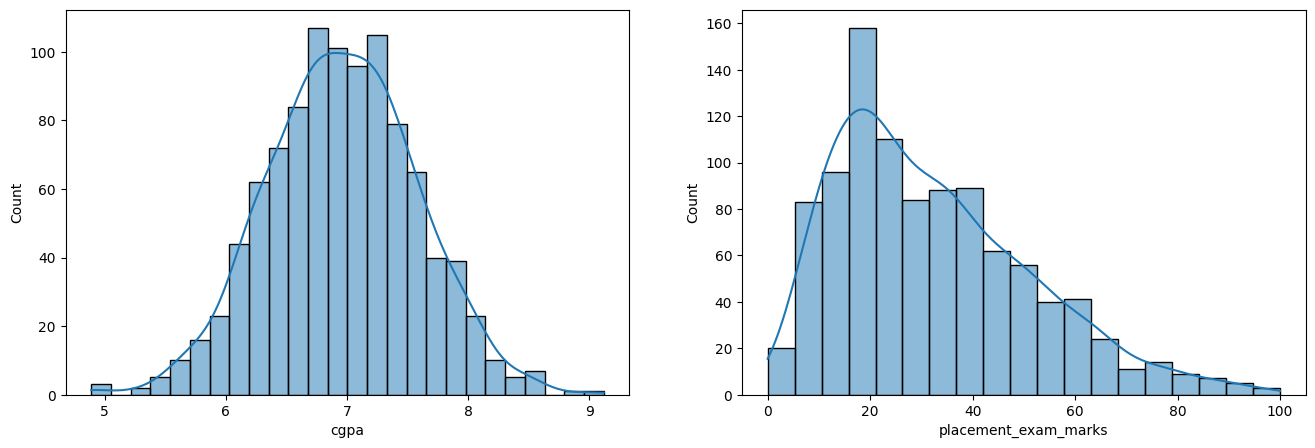

In [4]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.show()

In [5]:
df['placement_exam_marks'].describe()


count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

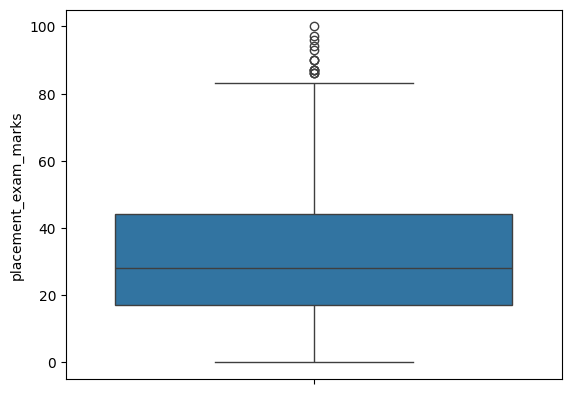

In [6]:
sns.boxplot(df['placement_exam_marks'])


In [7]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [8]:
percentile75


np.float64(44.0)

In [9]:
iqr = percentile75 - percentile25


In [10]:
iqr


np.float64(27.0)

In [11]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [12]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


In [13]:
df[df['placement_exam_marks'] > upper_limit]


,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [14]:
df[df['placement_exam_marks'] < lower_limit]


,cgpa,placement_exam_marks,placed


In [15]:
new_df = df[df['placement_exam_marks'] < upper_limit]


In [16]:
new_df.shape


(985, 3)

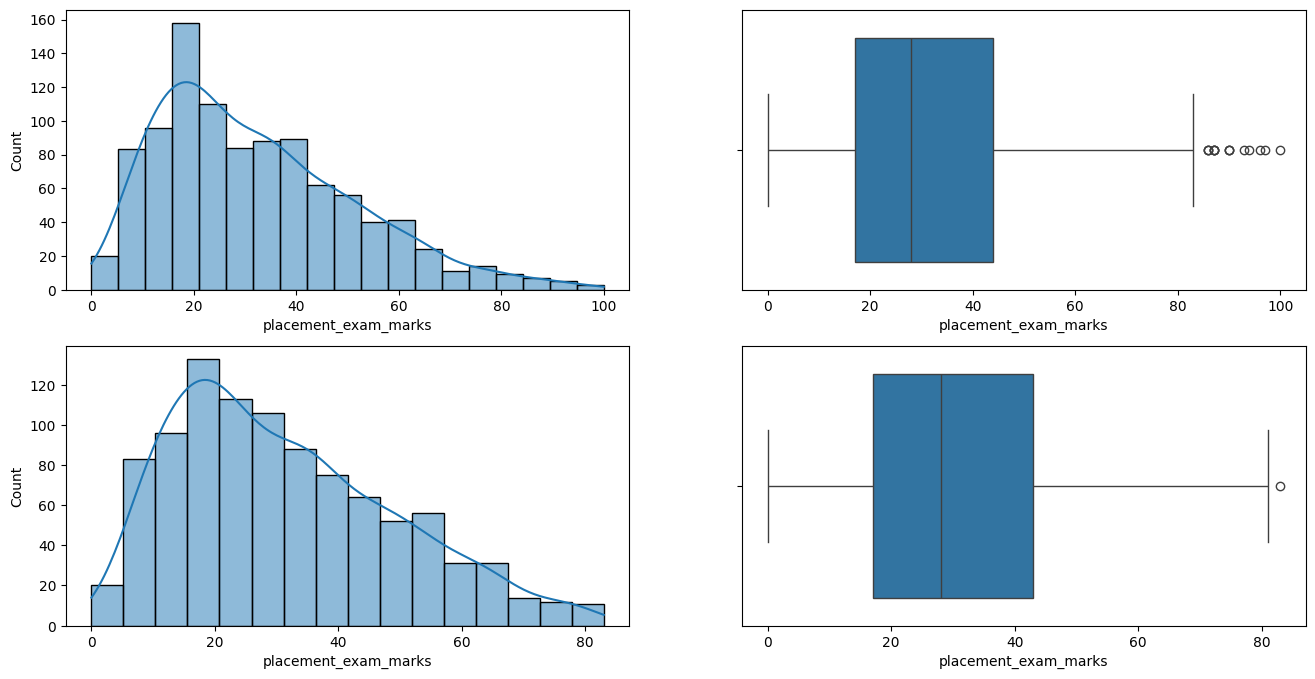

In [17]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.subplot(2, 2, 2)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(2, 2, 3)
sns.histplot(new_df['placement_exam_marks'], kde=True)

plt.subplot(2, 2, 4)
sns.boxplot(x=new_df['placement_exam_marks'])

plt.show()

In [18]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [24]:
np.where(df['cgpa'] > 7, True, False)

array([ True,  True,  True, False,  True,  True, False,  True, False,
        True, False, False, False, False,  True,  True, False,  True,
       False,  True, False,  True, False, False, False, False,  True,
       False,  True, False,  True,  True, False, False,  True,  True,
       False,  True, False,  True, False, False,  True,  True,  True,
       False,  True, False, False,  True, False, False,  True, False,
        True,  True, False,  True,  True,  True,  True,  True,  True,
       False, False, False, False,  True, False,  True, False, False,
        True, False, False, False,  True,  True,  True,  True, False,
        True,  True,  True, False, False,  True, False, False, False,
        True,  True, False, False,  True, False,  True,  True,  True,
        True, False, False, False, False, False, False, False,  True,
       False,  True, False, False,  True,  True, False,  True,  True,
        True, False, False, False, False, False, False, False,  True,
        True, False,

In [25]:
np.where(df['placement_exam_marks'] > 50, 'Pass', 'Fail')

array(['Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail',
       'Fail', 'Pass', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail',
       'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Pass', 'Fail',
       'Fail', 'Pass', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail',
       'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail',
       'Pass', 'Fail', 'Pass', 'Pass', 'Pass', 'Fail', 'Fail', 'Fail',
       'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail',
       'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Pass', 'Fail', 'Fail',
       'Pass', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail',
       'Fail', 'Fail', 'Fail', 'Pass', 'Fail', 'Fail', 'Fail', 'Fail',
       'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail',
       'Fail', 'Fail', 'Fail', 'Fail', 'Pass', 'Fail', 'Fail', 'Fail',
       'Fail', 'Pass', 'Pass', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail',
       'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail', 'Fail',
      

In [26]:
a = np.array([10, 20, 30, 40])

np.where(a > 25, 'High', 'Low')

array(['Low', 'Low', 'High', 'High'], dtype='<U4')

In [27]:
new_df_cap.shape


(1000, 3)

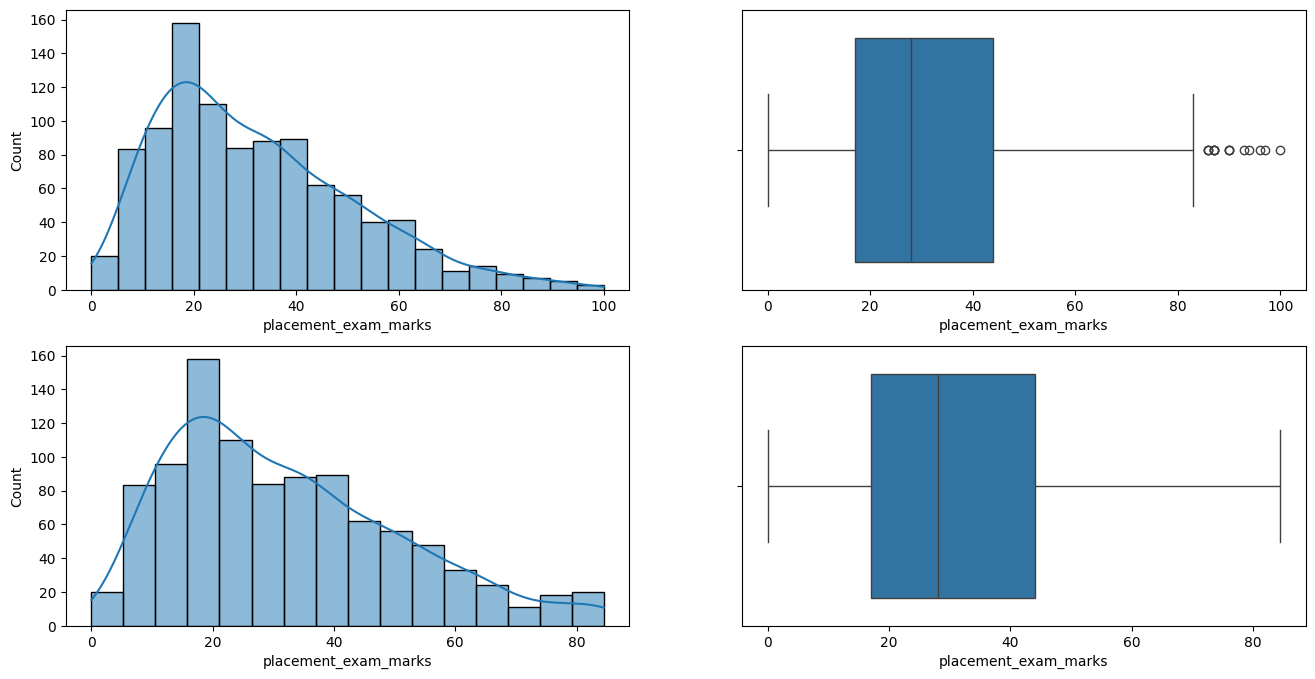

In [28]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.subplot(2, 2, 2)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(2, 2, 3)
sns.histplot(new_df_cap['placement_exam_marks'], kde=True)

plt.subplot(2, 2, 4)
sns.boxplot(x=new_df_cap['placement_exam_marks'])

plt.show()